In [6]:
import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestRegressor
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# ------------------------------------------------------
# 1. Load the sheets exactly as-is (NO RENAMING)
# ------------------------------------------------------
path = "TOP 2500 final.xlsx"

top_df = pd.read_excel(path, sheet_name="TOP 2500")
bottom_df = pd.read_excel(path, sheet_name="BOTTOM 2500")

# ------------------------------------------------------
# 2. Handle A+ column (bottom may not have it)
# ------------------------------------------------------
if "A & A+ Content" not in bottom_df.columns:
    bottom_df["A & A+ Content"] = "Not A+"

# Quantity columns
top_qty_col = "TOTAL QUANTITY"
bottom_qty_col = "QUANTITY"

# Drop missing target in TOP
top_df = top_df.dropna(subset=[top_qty_col])

# ------------------------------------------------------
# 3. Features (use exact names)
# ------------------------------------------------------
features = [
    "Total Images",
    "Total Videos",
    "Rating",
    "A & A+ Content",
    "Classification"
]

numeric = ["Total Images", "Total Videos"]
categorical = ["Rating", "A & A+ Content", "Classification"]

# Treat rating + A+ as categorical
top_df["Rating"] = top_df["Rating"].astype(str)
bottom_df["Rating"] = bottom_df["Rating"].astype(str)
bottom_df["A & A+ Content"] = bottom_df["A & A+ Content"].astype(str)

# ------------------------------------------------------
# 3b. Clean numeric columns: convert to numbers (fix "Not Found" etc.)
# ------------------------------------------------------
for df_ in (top_df, bottom_df):
    for col in numeric:
        # Anything non-numeric ("Not Found", "-", etc.) becomes NaN
        df_[col] = pd.to_numeric(df_[col], errors="coerce")

    # Also make sure quantity columns are numeric
    if top_qty_col in df_.columns:
        df_[top_qty_col] = pd.to_numeric(df_[top_qty_col], errors="coerce")
    if bottom_qty_col in df_.columns:
        df_[bottom_qty_col] = pd.to_numeric(df_[bottom_qty_col], errors="coerce")

# Drop any remaining missing target in TOP after coercion
top_df = top_df.dropna(subset=[top_qty_col])

# ------------------------------------------------------
# 4. Preprocessing + model
# ------------------------------------------------------
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
])

categorical_transformer = OneHotEncoder(handle_unknown="ignore")

preprocess = ColumnTransformer([
    ("num", numeric_transformer, numeric),
    ("cat", categorical_transformer, categorical)
])

rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    min_samples_leaf=2
)

model = Pipeline([
    ("prep", preprocess),
    ("rf", rf)
])

# ------------------------------------------------------
# 5. Train on TOP 2500
# ------------------------------------------------------
X_top = top_df[features]
y_top = top_df[top_qty_col]

model.fit(X_top, y_top)

# ------------------------------------------------------
# 6. Predict on BOTTOM 2500
# ------------------------------------------------------
X_bottom = bottom_df[features]

bottom_df["predicted_qty"] = model.predict(X_bottom)
bottom_df["residual"] = bottom_df["predicted_qty"] - bottom_df[bottom_qty_col]
bottom_df["pred_ratio"] = (bottom_df["predicted_qty"] + 1) / (bottom_df[bottom_qty_col] + 1)

# ------------------------------------------------------
# 7. Hidden gems
# ------------------------------------------------------
low_sales_cutoff = bottom_df[bottom_qty_col].quantile(0.40)
high_pred_cutoff = bottom_df["predicted_qty"].quantile(0.70)

hidden_gems = bottom_df[
    (bottom_df[bottom_qty_col] <= low_sales_cutoff) &
    (bottom_df["predicted_qty"] >= high_pred_cutoff)
].copy()

hidden_gems["hidden_gem_score"] = hidden_gems["residual"]
hidden_gems = hidden_gems.sort_values("hidden_gem_score", ascending=False)

print("\n🔍 Hidden Gems Found:", len(hidden_gems))

# 👉 Print SKU + AUCTION TITLE + key metrics
cols_to_show = [
    "SKU",
    "AUCTION TITLE",
    bottom_qty_col,          # actual quantity
    "predicted_qty",
    "hidden_gem_score",
    "pred_ratio"
]
# Only keep columns that actually exist (defensive)
cols_to_show = [c for c in cols_to_show if c in hidden_gems.columns]

print(hidden_gems[cols_to_show].head(15))



🔍 Hidden Gems Found: 751
         SKU                                      AUCTION TITLE  QUANTITY  \
1406  255377  Blown glass juice glasses, 'Aquamarine Bubbles...         1   
1084  329622                    Ceramic serving bowl, 'Grooves'         1   
2297  162792  Blown glass wine glasses, 'Lime Globe' (set of 4)         1   
416   427237  Handblown cocktail glasses, 'Intense Celebrati...         1   
1016  327812               Ceramic serving bowl, 'Banana Vibes'         1   
2489  162972                 Celadon ceramic vase, 'Wildflower'         1   
418   410493            Blown glass vase, 'Cinnabar Red Bottle'         1   
1166  332604      Ceramic decorative vase, 'Chulucanas Squares'         1   
1044  316733             Ceramic decorative vase, 'Divine Inca'         1   
935   323249          Ceramic decorative vase, 'Nicoya's Earth'         1   
887   345681       Ceramic decorative vase, 'Ancestral Culture'         1   
671   380308         Hand blown recycled glass vas

In [12]:
import pandas as pd
import numpy as np
from scipy import stats

# -----------------------------
# 0) LOAD & PREP DATA
# -----------------------------
file_path = "TOP 2500 final.xlsx"

# Read both sheets
top = pd.read_excel(file_path, sheet_name="TOP 2500")
bottom = pd.read_excel(file_path, sheet_name="BOTTOM 2500")

# Standardize column names
rename_map = {
    "TOTAL QUANTITY": "sales",
    "QUANTITY": "sales",
    "Total Images": "images",
    "Total Videos": "videos",
    "Rating": "rating",
    "A & A+ Content": "a_plus",
    "A & A+": "a_plus",
    "Classification": "category",
    "Review Count": "review_count"
}

top = top.rename(columns=rename_map)
bottom = bottom.rename(columns=rename_map)

# Combine into single df
df = pd.concat([top, bottom], ignore_index=True)

# -----------------------------
# Clean A/A+ content -> numeric
# -----------------------------
def clean_aplus(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower()
    if "a+" in s:
        return 2     # A+
    if s == "a":
        return 1     # A
    return 0         # treat others as No A

df["aplus_num"] = df["a_plus"].apply(clean_aplus)

# -----------------------------
# Clean rating -> numeric
# -----------------------------
import re

def clean_rating(x):
    if pd.isna(x):
        return np.nan
    m = re.search(r'([0-5](?:\.\d)?)', str(x))
    return float(m.group(1)) if m else np.nan

df["rating_num"] = df["rating"].apply(clean_rating)

# Ensure numeric types
df["sales"] = pd.to_numeric(df["sales"], errors="coerce")
df["images"] = pd.to_numeric(df["images"], errors="coerce")
df["videos"] = pd.to_numeric(df["videos"], errors="coerce")
df["review_count"] = pd.to_numeric(df["review_count"], errors="coerce")

# Drop rows with no sales
df_hg = df.dropna(subset=["sales"]).copy()

# -----------------------------
# 1) Segment into top and bottom 25% based on sales
# -----------------------------
q25 = df_hg["sales"].quantile(0.25)
q75 = df_hg["sales"].quantile(0.75)

top_mask = df_hg["sales"] >= q75
bottom_mask = df_hg["sales"] <= q25

top_df = df_hg[top_mask]
bottom_df = df_hg[bottom_mask]

print(f"Top 25% count: {len(top_df)}, Bottom 25% count: {len(bottom_df)}")

# -----------------------------
# 2) Run t-tests for key listing features
# -----------------------------
feature_cols = [
    "aplus_num",
    "rating_num",
    "images",
    "videos",
    "review_count"
]

print("\n=== Two-sample t-tests: Top vs Bottom 25% ===")

for col in feature_cols:
    if col not in df_hg.columns:
        print(f"\n[SKIP] {col} not in dataframe")
        continue

    top_vals = top_df[col].dropna()
    bottom_vals = bottom_df[col].dropna()

    if len(top_vals) < 10 or len(bottom_vals) < 10:
        print(f"\n[SKIP] {col}: not enough data for t-test")
        continue

    t_stat, p_val = stats.ttest_ind(top_vals, bottom_vals, equal_var=False)

    print(f"\nFeature: {col}")
    print(f"Top mean    = {top_vals.mean():.3f}")
    print(f"Bottom mean = {bottom_vals.mean():.3f}")
    print(f"t-stat      = {t_stat:.3f}, p-value = {p_val:.5f}")



Top 25% count: 1274, Bottom 25% count: 2501

=== Two-sample t-tests: Top vs Bottom 25% ===

Feature: aplus_num
Top mean    = 1.923
Bottom mean = 1.934
t-stat      = -1.218, p-value = 0.22340

Feature: rating_num
Top mean    = 4.438
Bottom mean = 4.384
t-stat      = 1.528, p-value = 0.12675

Feature: images
Top mean    = 7.757
Bottom mean = 7.286
t-stat      = 14.332, p-value = 0.00000

Feature: videos
Top mean    = 1.231
Bottom mean = 0.671
t-stat      = 27.480, p-value = 0.00000

Feature: review_count
Top mean    = 0.000
Bottom mean = 0.000
t-stat      = nan, p-value = nan


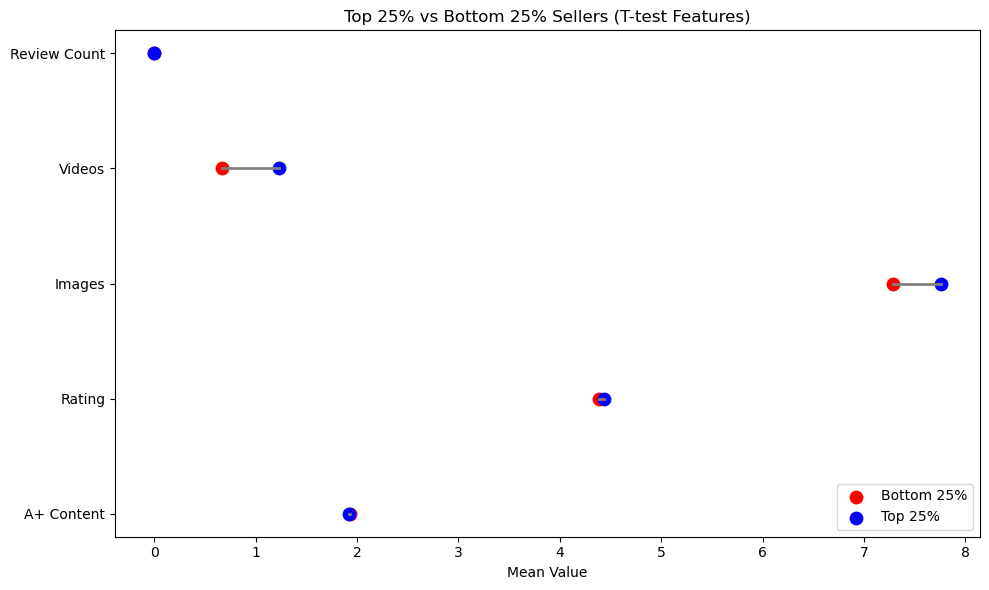

In [27]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Features you tested (same order as in your t-tests)
features = ["aplus_num", "rating_num", "images", "videos", "review_count"]

# Compute means for top and bottom groups
top_means = [top_df[f].mean() for f in features]
bottom_means = [bottom_df[f].mean() for f in features]

# Create a small dataframe for plotting
label_map = {
    "aplus_num": "A+ Content",
    "rating_num": "Rating",
    "images": "Images",
    "videos": "Videos",
    "review_count": "Review Count"
}

df_viz = pd.DataFrame({
    "Feature": [label_map[f] for f in features],
    "Top 25%": top_means,
    "Bottom 25%": bottom_means
})

# --- Dumbbell plot ---
plt.figure(figsize=(10, 6))

y_positions = np.arange(len(df_viz))

for i, row in df_viz.iterrows():
    # line between bottom and top means
    plt.plot(
        [row["Bottom 25%"], row["Top 25%"]],
        [i, i],
        color="gray",
        linewidth=2
    )
    # bottom 25% point
    plt.scatter(
        row["Bottom 25%"], i,
        color="red", s=80,
        label="Bottom 25%" if i == 0 else ""
    )
    # top 25% point
    plt.scatter(
        row["Top 25%"], i,
        color="blue", s=80,
        label="Top 25%" if i == 0 else ""
    )

plt.yticks(y_positions, df_viz["Feature"])
plt.xlabel("Mean Value")
plt.title("Top 25% vs Bottom 25% Sellers (T-test Features)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


In [62]:
#ANOVA across sales quartiles (Q1–Q4)
import pandas as pd
import numpy as np
from scipy import stats

# -----------------------------
# 0) Start from df_hg with clean sales
# -----------------------------
# If you haven't defined df_hg yet, do:
# df_hg = df.copy()

df_hg = df_hg.dropna(subset=["sales"]).copy()
df_hg["sales"] = pd.to_numeric(df_hg["sales"], errors="coerce")

# -----------------------------
# 1) Build quantile-based bins manually (handles duplicates safely)
# -----------------------------
quantiles = df_hg["sales"].quantile([0, 0.25, 0.50, 0.75, 1.0]).values

# Drop duplicate bin edges and sort
bins = np.unique(quantiles)

if len(bins) < 3:
    raise ValueError("Not enough variation in sales to form meaningful quartiles.")

# Create labels dynamically to match number of bins - 1
n_bins = len(bins) - 1
if n_bins == 4:
    labels = ["Q1 (lowest)", "Q2", "Q3", "Q4 (highest)"]
elif n_bins == 3:
    labels = ["Q1 (lowest)", "Q2", "Q3 (highest)"]
elif n_bins == 2:
    labels = ["Low", "High"]
else:
    labels = [f"Bin {i+1}" for i in range(n_bins)]

df_hg["sales_quartile"] = pd.cut(
    df_hg["sales"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

print("Quartile/bin distribution:")
print(df_hg["sales_quartile"].value_counts(dropna=False))

# -----------------------------
# 2) One-way ANOVA for key features across these bins
# -----------------------------
feature_cols = [
    "aplus_num",
    "rating_num",
    "images",
    "videos",
    "review_count",   # will be skipped if useless
    "price"           # will be skipped if not present
]

print("\n=== One-way ANOVA: Feature ~ Sales Bin ===")

for col in feature_cols:
    if col not in df_hg.columns:
        print(f"\n[SKIP] {col}: not in dataframe")
        continue

    groups = []
    labels_used = []

    for q_label, sub in df_hg.groupby("sales_quartile"):
        vals = sub[col].dropna()
        if len(vals) > 5:   # need enough data per group
            groups.append(vals)
            labels_used.append(q_label)

    if len(groups) < 2:
        print(f"\n[SKIP] {col}: not enough bins with data for ANOVA")
        continue

    F, p = stats.f_oneway(*groups)

    print(f"\nFeature: {col}")
    print("Bin means:")
    for lab, vals in zip(labels_used, groups):
        print(f"  {lab}: mean = {vals.mean():.3f} (n={len(vals)})")
    print(f"F-stat = {F:.3f}, p-value = {p:.5f}")


Quartile/bin distribution:
sales_quartile
Low     3847
High    1154
Name: count, dtype: int64

=== One-way ANOVA: Feature ~ Sales Bin ===

Feature: aplus_num
Bin means:
  Low: mean = 1.928 (n=3846)
  High: mean = 1.921 (n=1154)
F-stat = 0.656, p-value = 0.41784

Feature: rating_num
Bin means:
  Low: mean = 4.403 (n=2389)
  High: mean = 4.428 (n=1140)
F-stat = 0.666, p-value = 0.41433

Feature: images
Bin means:
  Low: mean = 7.382 (n=3846)
  High: mean = 7.770 (n=1154)
F-stat = 105.168, p-value = 0.00000

Feature: videos
Bin means:
  Low: mean = 0.782 (n=3846)
  High: mean = 1.242 (n=1154)
F-stat = 410.237, p-value = 0.00000

Feature: review_count
Bin means:
  Low: mean = 0.000 (n=1688)
  High: mean = 0.000 (n=20)
F-stat = nan, p-value = nan

[SKIP] price: not in dataframe


/var/folders/0s/qmtp3y411678hbf2m4jffg400000gn/T/ipykernel_59686/2638027152.py:68: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for q_label, sub in df_hg.groupby("sales_quartile"):
/opt/anaconda3/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:531: ConstantInputWarning: Each of the input arrays is constant; the F statistic is not defined or infinite
  res = hypotest_fun_out(*samples, **kwds)


In [58]:
#Top 20 Hidden Gem SKUs (Content-Rich but Underperforming in Sales)
import numpy as np
import pandas as pd

# -----------------------------
# 1) Select content features
# -----------------------------
content_features = ["videos", "images", "rating_num", "aplus_num"]

# Only keep features that exist
content_features = [c for c in content_features if c in df_hg.columns]

# -----------------------------
# 2) Standardize (z-score)
# -----------------------------
for col in content_features:
    mean = df_hg[col].mean()
    std = df_hg[col].std(ddof=1)
    df_hg[f"z_{col}"] = (df_hg[col] - mean) / std

# Fill NaN z-scores with 0
for col in content_features:
    df_hg[f"z_{col}"] = df_hg[f"z_{col}"].fillna(0)

# -----------------------------
# 3) Hidden Gem Score (Weighted)
# -----------------------------
weights = {
    "z_videos": 0.5 if "z_videos" in df_hg.columns else 0.0,
    "z_images": 0.3 if "z_images" in df_hg.columns else 0.0,
    "z_rating_num": 0.1 if "z_rating_num" in df_hg.columns else 0.0,
    "z_aplus_num": 0.1 if "z_aplus_num" in df_hg.columns else 0.0
}

df_hg["hidden_gem_score"] = 0

for zcol, w in weights.items():
    if zcol in df_hg.columns:
        df_hg["hidden_gem_score"] += w * df_hg[zcol]

# OPTIONAL: Clip outlier scores
df_hg["hidden_gem_score"] = df_hg["hidden_gem_score"].clip(-3, 3)


# -----------------------------
# 4) Filter Low Sellers ("Low" bin)
# -----------------------------
low_mask = df_hg["sales_quartile"].astype(str).str.contains("Low")
low_df = df_hg[low_mask].copy()


# -----------------------------
# 5) Optional filters to avoid junk listings
# -----------------------------
hidden_candidates = low_df[
    (low_df["images"] >= 5) &
    (low_df["videos"] >= 1) &
    (low_df["rating_num"].fillna(0) >= 4.0)
].copy()


# -----------------------------
# 6) Rank by Hidden Gem Score
# -----------------------------
hidden_candidates = hidden_candidates.sort_values(
    by="hidden_gem_score", ascending=False
)

# Choose identifier columns if they exist
id_cols = [c for c in ["ASIN", "SKU", "Product Name", "Title"] if c in hidden_candidates.columns]

cols_to_show = id_cols + [
    "category" if "category" in hidden_candidates.columns else None,
    "sales",
    "rating_num",
    "aplus_num",
    "images",
    "videos",
    "hidden_gem_score"
]

# Remove None
cols_to_show = [c for c in cols_to_show if c is not None]

hidden_gems_table = hidden_candidates[cols_to_show].reset_index(drop=True)


# -----------------------------
# 7) DISPLAY Top 20 Hidden Gems
# -----------------------------
print("\n===== TOP 20 HIDDEN GEMS =====")
hidden_gems_table.head(20)



===== TOP 20 HIDDEN GEMS =====


,ASIN,SKU,category,sales,rating_num,aplus_num,images,videos,hidden_gem_score
0,B08WH3YHRS,313322,Sculpture,1,5.0,2.0,9.0,2.0,1.288315
1,B0BGT56LGY,408064,Holiday Decor & Ornaments,5,5.0,2.0,9.0,2.0,1.288315
2,B07NQNZGD2,348728,Sculpture,5,5.0,2.0,9.0,2.0,1.288315
3,B07CM6627P,317409,Sculpture,1,5.0,2.0,9.0,2.0,1.288315
4,B07KTQ4MCF,337156,Tableware & Entertaining,1,5.0,2.0,9.0,2.0,1.288315
5,B0BGT3TQSN,393773,Jewelry Boxes,1,5.0,2.0,9.0,2.0,1.288315
6,B081GGF2VP,338413,Tableware & Entertaining,1,5.0,2.0,9.0,2.0,1.288315
7,B08WHLN1K4,332424,Decor Accessories,1,5.0,2.0,9.0,2.0,1.288315
8,B07Y3YR68J,329137,Sculpture,1,5.0,2.0,9.0,2.0,1.288315
9,B07KRDYFHC,322755,Vases,4,5.0,2.0,9.0,2.0,1.288315


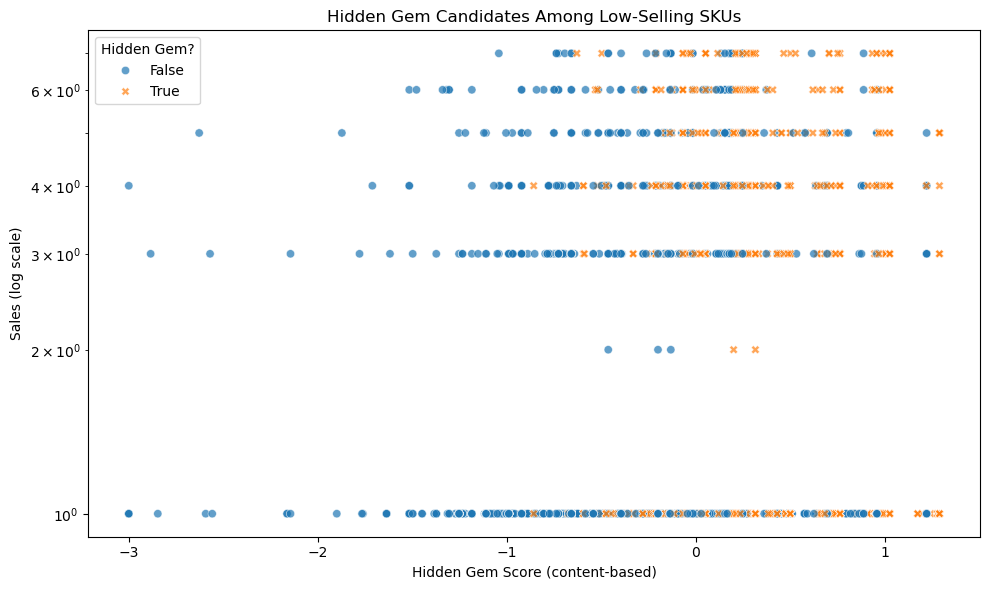

In [60]:
import seaborn as sns
import matplotlib.pyplot as plt

# Make a copy of low sellers
low_df = df_hg[df_hg["sales_quartile"].astype(str).str.contains("Low")].copy()

# Mark which of them are hidden gems (based on hidden_candidates index)
low_df["is_hidden_gem"] = False
low_df.loc[hidden_candidates.index, "is_hidden_gem"] = True

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=low_df,
    x="hidden_gem_score",
    y="sales",
    hue="is_hidden_gem",
    style="is_hidden_gem",
    alpha=0.7
)

plt.yscale("log")  # sales are skewed, log scale makes it readable
plt.xlabel("Hidden Gem Score (content-based)")
plt.ylabel("Sales (log scale)")
plt.title("Hidden Gem Candidates Among Low-Selling SKUs")
plt.legend(title="Hidden Gem?")
plt.tight_layout()
plt.show()



=== Correlation Matrix (Pearson) ===
                 sales  aplus_num  rating_num    images    videos  \
sales         1.000000   0.020414    0.019650  0.060643  0.126424   
aplus_num     0.020414   1.000000   -0.005262  0.018239 -0.014292   
rating_num    0.019650  -0.005262    1.000000  0.022281  0.043911   
images        0.060643   0.018239    0.022281  1.000000 -0.083257   
videos        0.126424  -0.014292    0.043911 -0.083257  1.000000   
review_count       NaN        NaN         NaN       NaN       NaN   

              review_count  
sales                  NaN  
aplus_num              NaN  
rating_num             NaN  
images                 NaN  
videos                 NaN  
review_count           NaN  


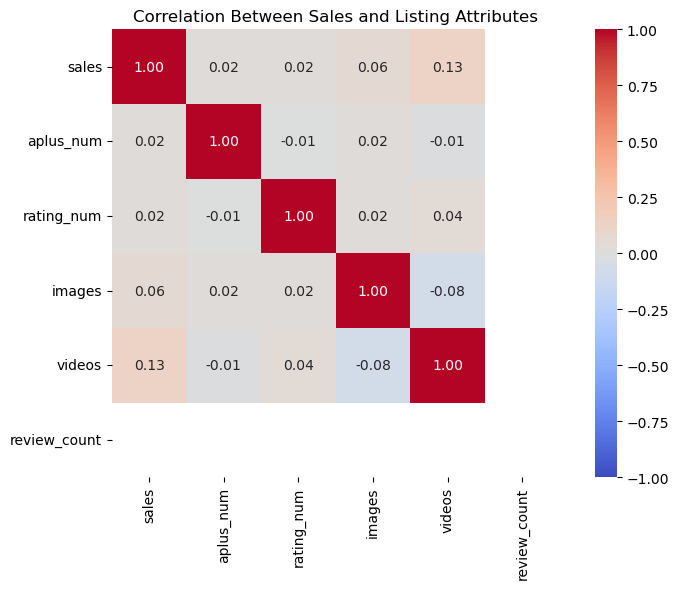

In [64]:
#Correlation Analysis (Sales vs Listing Attributes)

import seaborn as sns
import matplotlib.pyplot as plt

# -----------------------------
# 1) Build correlation dataframe
# -----------------------------
corr_cols = [
    "sales",
    "aplus_num",
    "rating_num",
    "images",
    "videos",
    "review_count",
    "price"
]

existing_cols = [c for c in corr_cols if c in df_hg.columns]

corr_df = df_hg[existing_cols].corr(method="pearson")

print("\n=== Correlation Matrix (Pearson) ===")
print(corr_df)

# -----------------------------
# 2) Optional: correlation heatmap
# -----------------------------
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_df,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    square=True
)
plt.title("Correlation Between Sales and Listing Attributes")
plt.tight_layout()
plt.show()

